In [1]:
import pandas as pd

# Caminho do CSV salvo no notebook anterior
arquivo = "dataset_unificado.csv"

# Carregar o dataset
df = pd.read_csv(arquivo, sep=";", encoding="utf-8-sig")

# Informações básicas
print("📊 Informações gerais do Dataset Unificado")
print(f"Total de registros: {len(df)}")
print(f"Total de colunas: {len(df.columns)}")
print(f"Colunas: {list(df.columns)}\n")

# Distribuição absoluta e percentual das classes
dist_abs = df['label'].value_counts()
dist_pct = df['label'].value_counts(normalize=True) * 100

print("Distribuição absoluta das classes:")
print(dist_abs, "\n")

print("Distribuição percentual das classes:")
print(dist_pct.round(2), "\n")

# Número de fontes e contagem
print(f"Número de fontes únicas: {df['fonte'].nunique()}")
print("Fontes e seus respectivos tamanhos:")
print(df['fonte'].value_counts(), "\n")

# Métricas de tamanho dos textos
df['tamanho_texto'] = df['texto'].astype(str).apply(len)
print(f"Tamanho médio dos textos: {df['tamanho_texto'].mean():.2f} caracteres")
print(f"Tamanho mínimo: {df['tamanho_texto'].min()} caracteres")
print(f"Tamanho máximo: {df['tamanho_texto'].max()} caracteres")


📊 Informações gerais do Dataset Unificado
Total de registros: 30730
Total de colunas: 4
Colunas: ['texto', 'label', 'categoria', 'fonte']

Distribuição absoluta das classes:
label
0    20875
1     9855
Name: count, dtype: int64 

Distribuição percentual das classes:
label
0    67.93
1    32.07
Name: proportion, dtype: float64 

Número de fontes únicas: 4
Fontes e seus respectivos tamanhos:
fonte
fake_recogna           11886
central_de_fatos       11644
fakebr_nilc             7199
fakenews_multilabel        1
Name: count, dtype: int64 

Tamanho médio dos textos: 2731.55 caracteres
Tamanho mínimo: 3 caracteres
Tamanho máximo: 97220 caracteres


In [2]:
df.head(10)

,texto,label,categoria,fonte,tamanho_texto
0,Ancine aprovou em 2019 a captação de 530 mil r...,0,['Políticas públicas'],central_de_fatos,12096
1,Parte dos trechos das gravações utilizadas no ...,0,['Políticas públicas'],central_de_fatos,7981
2,"Em uma publicação no Twitter, o deputado usa c...",0,['Pandemia'],central_de_fatos,10524
3,"Procurada pelo Comprova, médica enviou 34 estu...",0,['Pandemia'],central_de_fatos,12443
4,Ao contrário do que afirma uma médica em vídeo...,0,['Pandemia'],central_de_fatos,15013
5,Imagem que circula nas redes sociais é de um t...,0,['Pandemia'],central_de_fatos,5967
6,Texto distorce declarações de especialista cub...,0,['Pandemia'],central_de_fatos,13633
7,Publicação no Instagram comemorava a chegada d...,0,['Pandemia'],central_de_fatos,9296
8,Linhagens celulares desenvolvidas a partir de ...,0,['Pandemia'],central_de_fatos,14457
9,"O Banco Central (BC), responsável exclusivo pe...",0,['Políticas públicas'],central_de_fatos,11318


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/victoriareis/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Gerando bigramas para Label 0...


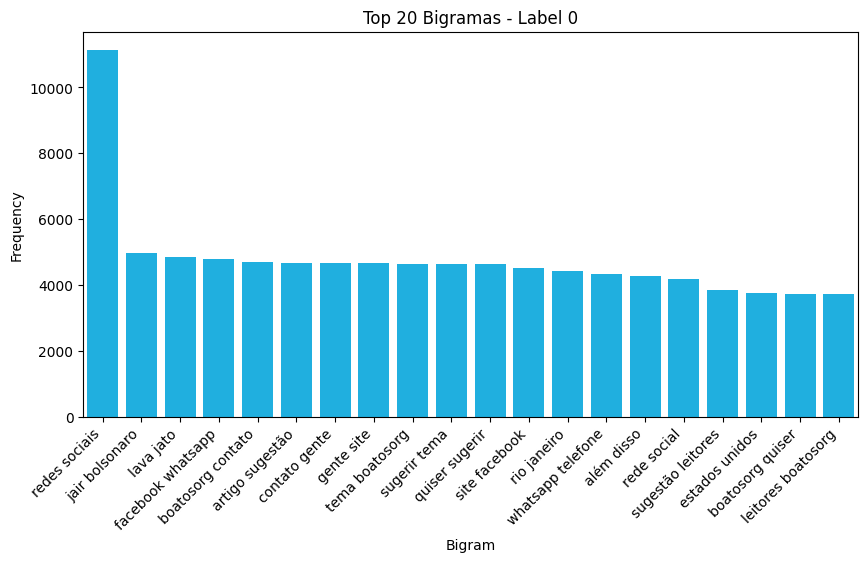

Gerando bigramas para Label 1...


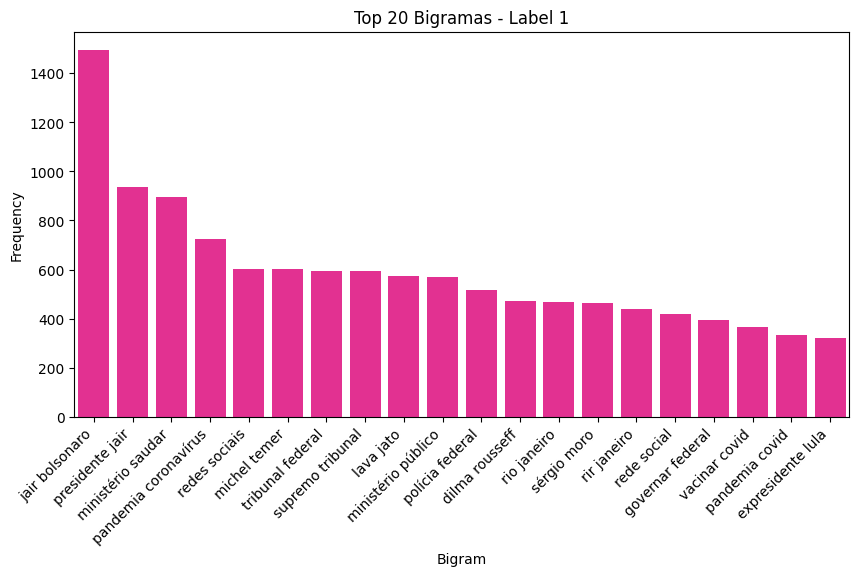

Gerando distribuição de tamanhos...


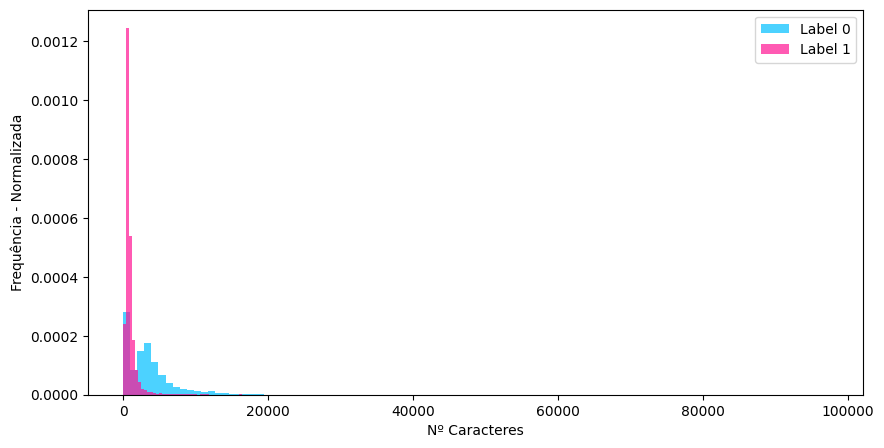

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords

# Baixar stopwords (se ainda não baixado)
nltk.download('stopwords')
stop_words = set(stopwords.words('portuguese'))

# =========================
# 1. Carregar dataset
# =========================
df = pd.read_csv("dataset_unificado.csv", sep=";", encoding="utf-8-sig")

# Garantir que label é int
df['label'] = df['label'].astype(int)

# =========================
# Função de limpeza de texto
# =========================
def limpar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r'[^a-záéíóúàâêîôûãõç\s]', '', texto)  # remover pontuação/números
    tokens = [t for t in texto.split() if t not in stop_words]
    return " ".join(tokens)

df['texto_limpo'] = df['texto'].apply(limpar_texto)

# =========================
# 2. Função para top bigramas
# =========================
def plot_top_bigrams(df, label_value, cor, top_n=20):
    textos = df[df['label'] == label_value]['texto_limpo']
    
    vectorizer = CountVectorizer(ngram_range=(2, 2))
    X = vectorizer.fit_transform(textos)
    sum_words = X.sum(axis=0)
    
    palavras_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    palavras_freq = sorted(palavras_freq, key=lambda x: x[1], reverse=True)[:top_n]
    
    bigram_df = pd.DataFrame(palavras_freq, columns=['Bigram', 'Frequency'])
    
    plt.figure(figsize=(10,5))
    sns.barplot(x='Bigram', y='Frequency', data=bigram_df, color=cor)
    plt.xticks(rotation=45, ha='right')
    plt.title(f"Top {top_n} Bigramas - Label {label_value}")
    plt.show()

# =========================
# 3. Função para distribuição de tamanho
# =========================
def plot_length_distribution(df):
    df['text_len'] = df['texto'].astype(str).apply(len)
    
    plt.figure(figsize=(10,5))
    plt.hist(df[df['label']==0]['text_len'], bins=100, alpha=0.7, density=True, color='deepskyblue', label='Label 0')
    plt.hist(df[df['label']==1]['text_len'], bins=100, alpha=0.7, density=True, color='deeppink', label='Label 1')
    plt.xlabel("Nº Caracteres")
    plt.ylabel("Frequência - Normalizada")
    plt.legend()
    plt.show()

# =========================
# 4. Executar análises
# =========================
print("Gerando bigramas para Label 0...")
plot_top_bigrams(df, label_value=0, cor='deepskyblue')

print("Gerando bigramas para Label 1...")
plot_top_bigrams(df, label_value=1, cor='deeppink')

print("Gerando distribuição de tamanhos...")
plot_length_distribution(df)


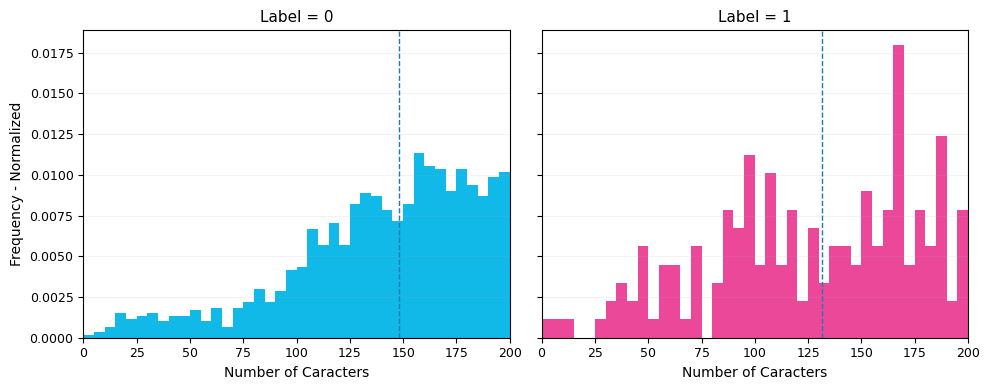

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- carregar ---
df = pd.read_csv("dataset_unificado.csv", sep=";", encoding="utf-8-sig")
df["n_chars"] = df["texto"].astype(str).str.len()

# --- define faixa do eixo X pelo percentil 99 (cap) e trava no máx. 200 ---
cap_p99 = int(np.percentile(df["n_chars"], 99))
CAP = min(cap_p99, 200)  # referência usa 0–200

# --- separa classes e filtra (NÃO usar clip) ---
g0 = df.loc[(df["label"] == 0) & (df["n_chars"] <= CAP), "n_chars"]
g1 = df.loc[(df["label"] == 1) & (df["n_chars"] <= CAP), "n_chars"]

# --- bins de 5 em 5 p/ suavidade controlada
bins = np.arange(0, CAP + 5, 5)

# --- cores (iguais à sua paleta)
c0 = "#10B9E7"  # azul
c1 = "#EC4899"  # magenta

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# Label 0
axes[0].hist(g0, bins=bins, density=True, color=c0, edgecolor="none")
axes[0].set_title("Label = 0", fontsize=11)
axes[0].set_xlabel("Number of Caracters")
axes[0].set_ylabel("Frequency - Normalized")
axes[0].axvline(g0.median(), linestyle="--", linewidth=1)

# Label 1
axes[1].hist(g1, bins=bins, density=True, color=c1, edgecolor="none")
axes[1].set_title("Label = 1", fontsize=11)
axes[1].set_xlabel("Number of Caracters")
axes[1].axvline(g1.median(), linestyle="--", linewidth=1)

for ax in axes:
    ax.set_xlim(0, CAP)
    ax.grid(axis="y", alpha=0.2, linewidth=0.5)
    ax.tick_params(axis="both", labelsize=9)

fig.tight_layout()
plt.show()
